In [74]:
import numpy as np
import pandas as pd
from PKA_Sleep import Graphing_Utils as graph
graph.make_bigandbold()
import matplotlib.pyplot as plt
from scipy import stats

In [55]:
stim_traces = np.load('/Volumes/yaochen/Active/zach/flip/multi_exp_traces_dict.npy', allow_pickle = True).item()
stim_traces['traces'] = list(stim_traces['traces'])
t = stim_traces['time']
stim_traces.pop('time')
stim_df = pd.DataFrame(stim_traces).dropna()
trace_colors = {10:'#2266AB', 100: '#74ACCF', 500: '#F26D44', 1000: '#D63127'}


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


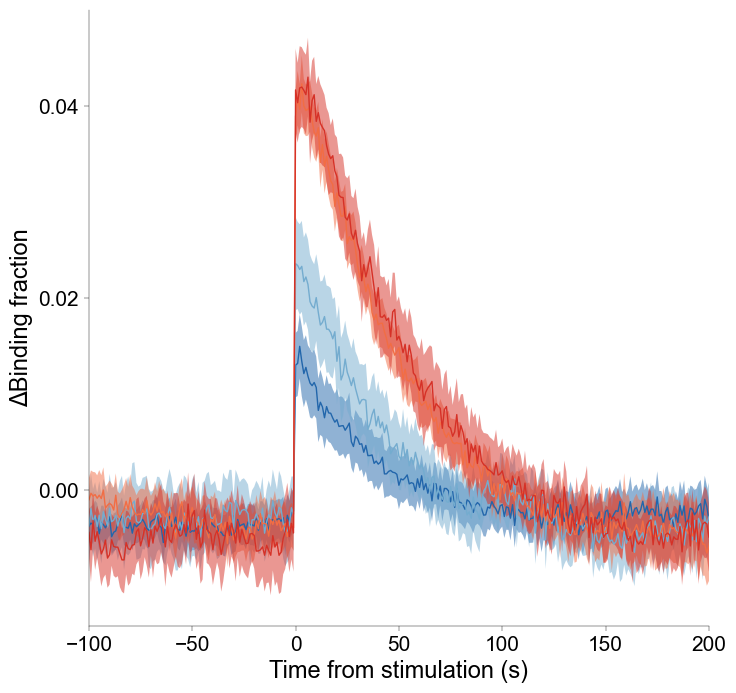

In [80]:
fig, ax = plt.subplots(figsize = [8,8])
for s in trace_colors.keys():
    stim_df.loc[(stim_df['stim_power(uW)'] == 100.5) & (stim_df['stim_length'] == s)]
    trace_list = [-(trace-trace[0]) for trace in stim_df['traces'].loc[
        (stim_df['stim_power(uW)'] == 100.5) & (stim_df['stim_length'] == s)].to_numpy()]
    trace_vals = np.stack(trace_list)
    trace_mn = np.nanmean(trace_vals, axis = 0)
    trace_std = stats.sem(trace_vals, axis = 0, nan_policy = 'omit')
    graph.linegraph_w_error(ax, t, trace_mn, trace_std, color=trace_colors[s], label=None, linewidth=1, linestyle='-', alpha=0.5)
ax.set_xlim([-100,200])
ax.set_yticks([0, 0.02, 0.04])
graph.label_axes(ax, y = 'ΔBinding fraction', x = 'Time from stimulation (s)')
graph.thick_axes(fig, ax, width = 0.3)
fig.savefig('/Users/lizzie/Library/CloudStorage/Box-Box/ChenLab/Lizzie/Thesis_Figures/Component_Figures/Figure_1/biPAC_stim_fig.ps')